In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
data = pd.read_csv('/content/_regdata_new.csv')

In [ ]:
data.describe()

,Unnamed: 0,StID,SAT,GPA
count,81.000000,81.000000,81.000000,81.000000
mean,41.049383,149.049383,1350.185185,3.361481
std,24.604827,29.747227,102.931666,0.220738
min,0.000000,101.000000,1134.000000,2.740000
25%,20.000000,122.000000,1275.000000,3.210000
50%,41.000000,149.000000,1350.000000,3.390000
75%,62.000000,175.000000,1434.000000,3.510000
max,83.000000,198.000000,1550.000000,3.810000


In [ ]:
y = data['GPA']
x = data['SAT']

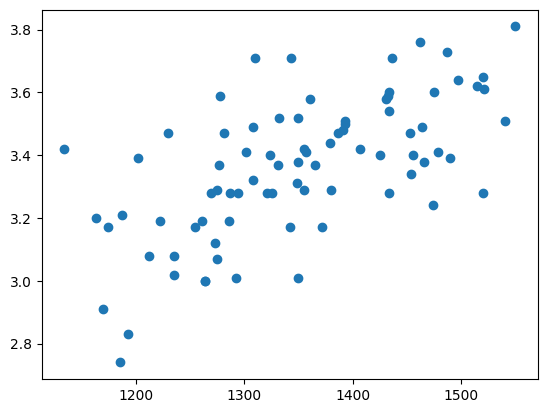

In [ ]:
plt.scatter(x,y)

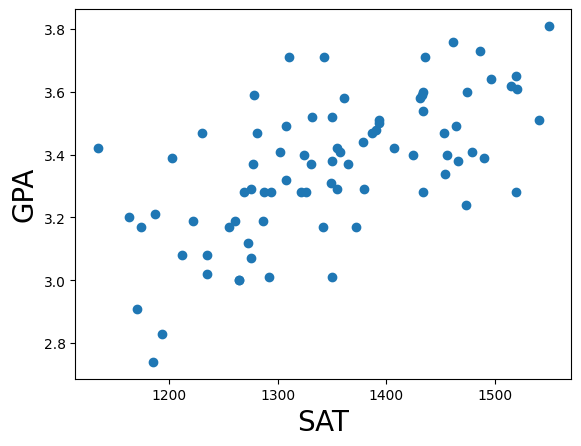

In [ ]:
plt.scatter(x,y)
plt.xlabel('SAT', fontsize = 20)
plt.ylabel('GPA', fontsize = 20)
plt.show()

In [ ]:
data[['SAT','GPA']].corr()

,SAT,GPA
SAT,1.000000,0.634194
GPA,0.634194,1.000000


In [ ]:
import seaborn as sns


<Axes: >

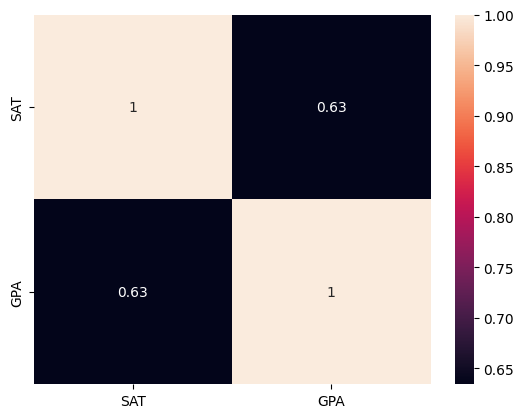

In [ ]:
sns.heatmap(data[['SAT','GPA']].corr(),annot = True)


In [ ]:
from scipy.stats import linregress

In [ ]:
slope,intercept,r_value,p_value,std_err = linregress(x,y)

In [ ]:
print("Slope:", slope)

Slope: 0.0013600349643199277


<function matplotlib.pyplot.show(close=None, block=None)>

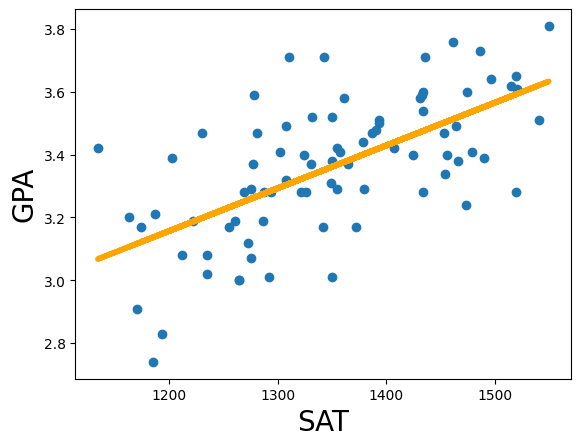

In [ ]:
plt.scatter(x,y)
y1 = slope*x + intercept
fig = plt.plot(x,y1,lw=4, c='orange',label = 'regression line')
plt.xlabel('SAT', fontsize = 20)
plt.ylabel('GPA', fontsize = 20)
plt.show

In [ ]:
from scipy.stats import linregress

In [ ]:
y1 = data['GPA']
x1 = data['SAT']

In [ ]:
slope, intercept, r_value, p_value, std_err = linregress(x1, y1)

In [ ]:
y2 = slope*x1 + intercept

Text(0, 0.5, 'GPA')

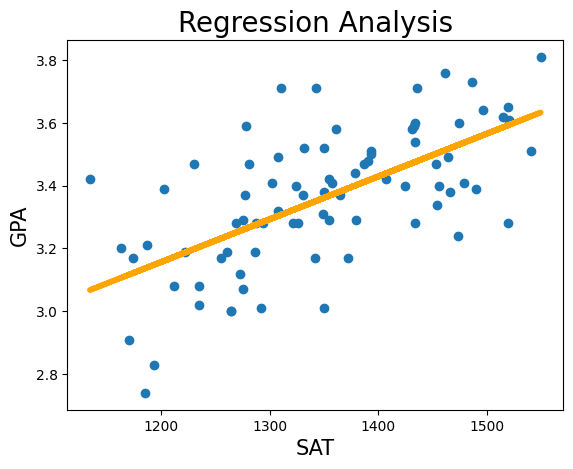

In [ ]:
fig = plt.figure
plt.scatter(x1,y1)

fig = plt.plot(x1,y2, lw=4, c='orange')

plt.title("Regression Analysis", fontsize = 20)
plt.xlabel('SAT', fontsize = 15)
plt.ylabel('GPA', fontsize = 15)


In [ ]:

## using y2 = slope*x1 + intercept

In [ ]:
givenSAT= 1450
predGPA = slope* givenSAT + intercept
predGPA

np.float64(3.4972331195867485)

In [ ]:
df_p = pd.DataFrame({"ActualGPA":y1,"Predicted":y2})
df_p.head()

,ActualGPA,Predicted
0,3.42,3.368030
1,3.48,3.416991
2,2.91,3.116423
3,3.41,3.370750
4,3.28,3.328589


<Axes: >

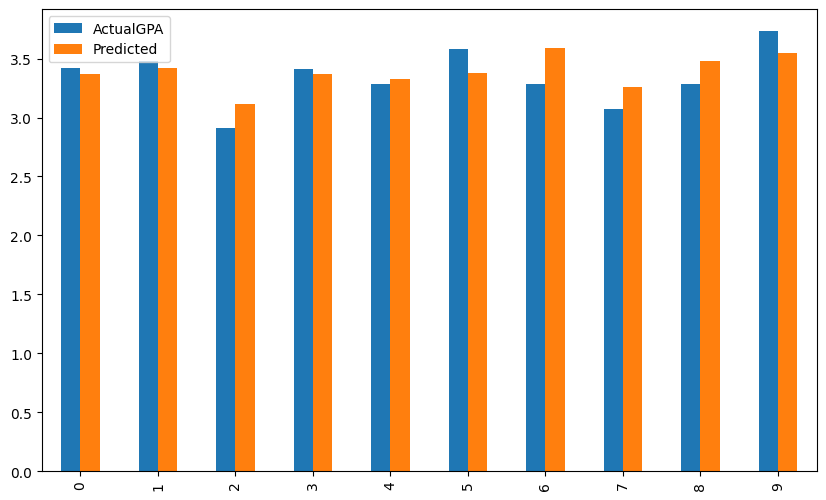

In [ ]:
df_p.head(10).plot(kind="bar",figsize=(10,6))

In [ ]:
df_a_p = pd.DataFrame({**data, "PredictedGPA":y2})
df_a_p.head()

,Unnamed: 0,StID,SAT,GPA,PredictedGPA
0,0,101,1355,3.42,3.368030
1,1,102,1391,3.48,3.416991
2,2,103,1170,2.91,3.116423
3,3,104,1357,3.41,3.370750
4,4,105,1326,3.28,3.328589


In [ ]:
import seaborn as sns


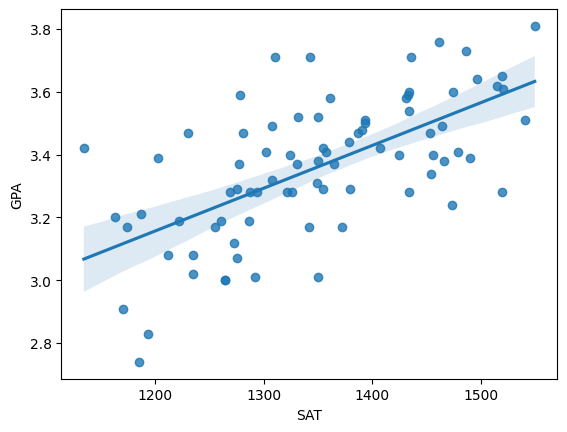

In [ ]:
p = sns.regplot(data=data, x=data.SAT, y=data.GPA)

<Axes: xlabel='SAT', ylabel='GPA'>

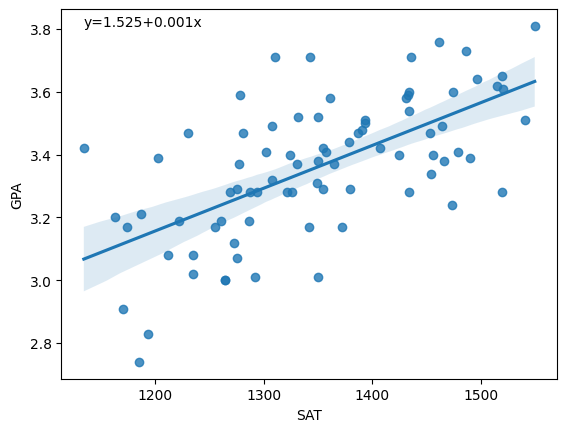

In [ ]:

plt.text(min(data.SAT),max(data.GPA),'y=' + str(round(intercept,3)) + '+' + str(round(slope,3)) + 'x')
sns.regplot(data=data,x=data.SAT,y=data.GPA)

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X = data.SAT
y = data.GPA

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.3 , random_state=1)

X_train = X_train.to_numpy().reshape(-1,1)
X_test = X_test.to_numpy().reshape(-1,1)


In [ ]:
from sklearn.linear_model import LinearRegression
rgsr = LinearRegression()


In [ ]:
model= rgsr.fit(X_train,y_train)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
y = pd.DataFrame({'Original': y_test, 'Predicted': y_pred})
y.head()

,Original,Predicted
63,3.76,3.504437
27,3.65,3.573986
31,3.19,3.293393
69,3.00,3.267013
46,3.17,3.159093


<Axes: >

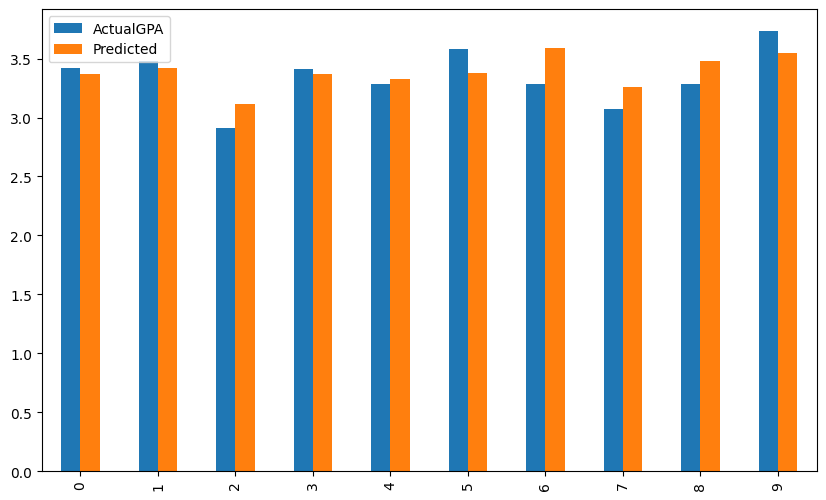

In [ ]:
df_p.head(10).plot(kind="bar",figsize=(10,6))

In [ ]:
from sklearn import metrics

In [ ]:
print('Evaluation indicators')
print("MAE: \t" , metrics.mean_absolute_error(y_test,y_pred))
print("MSE: \t" , metrics.mean_squared_error(y_test,y_pred))
print("RMSE: \t",  metrics.mean_squared_error(y_test,y_pred)**(0.5))
print("R-Squared:", metrics.r2_score(y_test,y_pred))

Evaluation indicators
MAE: 	 0.1364566158325926
MSE: 	 0.030593767925858665
RMSE: 	 0.17491074274000057
R-Squared: 0.5115887530482646


In [ ]:
import numpy as np

In [ ]:
b0 = 0.0
b1 = 0.0
learning_rate = 0.0000001
epochs = 1000
n = float(len(X_train))

In [ ]:
x_vals = X_train.flatten()
y_vals = y_train.to_numpy()

In [ ]:
for i in range(epochs):

    y_current = b1 * x_vals + b0

    D_b1 = (-2/n) * sum(x_vals * (y_vals - y_current))
    D_b0 = (-2/n) * sum(y_vals - y_current)

    b1 = b1 - learning_rate * D_b1
    b0 = b0 - learning_rate * D_b0

print(f"Final intercept (b0): {b0}")
print(f"Final slope (b1): {b1}")

Final intercept (b0): 3.620987463433299e-06
Final slope (b1): 0.002496526685303687


In [ ]:
y_pred_gd = b1 * X_test.flatten() + b0

In [ ]:
from sklearn import metrics

print('---Gradient Descent Evaluation ---')
print("MAE: \t" , metrics.mean_absolute_error(y_test,y_pred_gd))
print("MSE: \t" , metrics.mean_squared_error(y_test,y_pred_gd))
print("RMSE: \t",  np.sqrt(metrics.mean_squared_error(y_test,y_pred_gd)))
print("R-squared:", metrics.r2_score(y_test,y_pred_gd))


---Gradient Descent Evaluation ---
MAE: 	 0.16182890906899838
MSE: 	 0.03878283121884255
RMSE: 	 0.1969335705735377
R-squared: 0.38085524470807897
